In [1]:
import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR
from surrogates_interface.transformers import Transformer

import matplotlib.pyplot as plt
from surrogates_interface.surrogates import TensorFlowModel

import numpy as np
import pandas as pd
import xarray as xr
from py_wake.site import UniformSite
# from py_wake.wind_farm_models.engineering_models import PropagateDownwind
from py_wake.examples.data.hornsrev1 import V80
from dependencies import compute_sector_average, PropagateDownwindNoSelfInduction, predict_loads_sector_average
# from py_wake_addiditonal_dependencies import  PropagateDownwindNoSelfInduction, predict_loads_sector_average, predict_loads_rotor_average
# from tool_agnostic import compute_sector_average
from abc import ABC
from py_wake.deficit_models import ZongGaussianDeficit, NOJDeficit
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.flow_map import HorizontalGrid
from py_wake.site._site import UniformSite
from py_wake.site.shear import PowerShear
from py_wake.turbulence_models import CrespoHernandez, GCLTurbulence,STF2017TurbulenceModel
# from py_wake.deficit_models.gaussian import GaussianDeficit
from py_wake.site import UniformSite
from py_wake.examples.data.hornsrev1 import V80, Hornsrev1Site
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Hides INFO and WARNING messages
import tensorflow as tf
tf.get_logger().setLevel('ERROR')         # Hides tf.function retracing warnings
from iea3_4_pywake_openfast_1 import iea3_4
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.wind_turbines import WindTurbine, WindTurbines
from data.turbine.iea_22s import IEA22s
from py_wake.deficit_models.gaussian import ZongGaussianDeficit
from py_wake.superposition_models import WeightedSum, SqrMaxSum
from py_wake.wind_farm_models import PropagateDownwind
from py_wake.turbulence_models import CrespoHernandez
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.site._site import UniformSite
from py_wake.deficit_models.utils import ct2a_mom1d
from data.turbine.iea_22s import IEA22s


# Updated list of available surrogate channels based on files you have
channels = [
    "SA_blade_root_ip", "SA_blade_root_oop","SA_blade_root_projected", "SA_shaft_oop", "SA_shaft_yaw",
    "SA_tbss", "SA_tbfa", "SA_tower_top_fa", "SA_tower_torsion","SA_tower_top_ss","SA_tower_base_projected"
]

surrogates = {}
for ch in channels:
    model_path = os.path.join("models", f"{ch}.keras")
    scaler_path = os.path.join("models", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)


2025-07-07 19:13:29.678673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751908409.735278   44040 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751908409.751021   44040 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751908409.852947   44040 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751908409.852987   44040 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751908409.852989   44040 computation_placer.cc:177] computation placer alr

<xarray.SimulationResult> Size: 3kB
Dimensions:       (wt: 34, time: 1)
Coordinates:
  * wt            (wt) int64 272B 0 1 2 3 4 5 6 7 8 ... 26 27 28 29 30 31 32 33
    wd            (time) int64 8B 210
    ws            (time) int64 8B 8
    type          (wt) int64 272B 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
  * time          (time) int64 8B 0
Data variables: (12/15)
    WS_eff        (wt, time) float64 272B 8.0 7.869 8.0 ... 7.743 7.424 6.119
    TI_eff        (wt, time) float64 272B 0.1 0.1048 0.1 ... 0.1274 0.1458
    Power         (wt, time) float64 272B 6.229e+06 5.936e+06 ... 2.824e+06
    CT            (wt, time) float64 272B 0.6134 0.6143 0.6134 ... 0.617 0.6164
    yaw           (wt) int64 272B 30 30 30 30 30 30 30 ... 30 30 30 30 30 30 30
    tilt          (wt) int64 272B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    ...            ...
    y             (wt) float64 272B 0.0 1.184e+03 130.6 ... 1.252e+04 1.415e+04
    WD            int64 8B 210
    TI            float64 8B 0.1
    wd_bin_size   float64 8B 360.0
    WS            float64 8B 8.0
    P             float64 8B 1.0

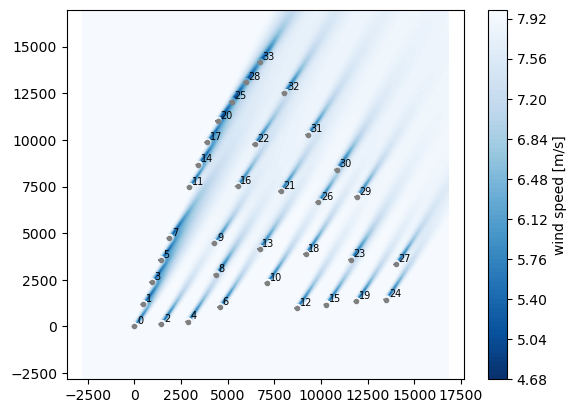

In [2]:
# %%prun
wt = IEA22s()

u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=wt.diameter(),
                    hub_height=wt.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])

# Wind farm layout
D = wt.diameter()
x = np.array([0, 6, 12, 0, 6, 12]) *18* D
y = np.array([0, 0, 0, 6, 6, 6]) *18* D


# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=None,
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))


# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site=site,
    windTurbines=wts,
    wake_deficitModel=deficit_model,
    superpositionModel=WeightedSum(),
    deflectionModel=JimenezWakeDeflection(),
    turbulenceModel=turbulence_model,
)


# site.ds
layout_subset = pd.read_csv(r"data/HKN_layout_subset_with_scaled.csv")
x_scaled = layout_subset["x_scaled"]
y_scaled = layout_subset["y_scaled"]

sim_res = wfm(
    x=x_scaled,
    y=y_scaled,
    type=np.full(34, True),  # Only first three turbines are active
    TI=np.full(1, 0.1),            # single turbulence intensity
    wd=np.full(1, 210),              # single wind direction
    ws=np.full(1, 8),              # single wind speed
    yaw=np.full(34, 30),        # array yaw values
    tilt=np.full(34, 0),      # array of tilt values
    time=True,
    power_demand=np.full(34, 100),     # array of power level values
)

sim_res.flow_map().plot_wake_map()  # this will take a long time





sim_res

In [3]:
# %%prun
sa = compute_sector_average(sim_res, 
                            n_radius=10,
    n_azimuth=37,
    look="downwind")

# # print(sa.loc[{'quantity':'TI_eff'}])


In [4]:
# Predict loads using sector-averaged inflow
loads = predict_loads_sector_average(
    surrogates,   # dictionary of TensorflowSurrogate objects
    sim_res,      # simulation result from PyWake
    sa,           # sector-averaged inflow (the variable `sa`)
    np.full(34, 0),   # additional input 1: yaw
    np.full(34, 50)  # additional input 2: power demand
)

In [5]:
# drop the length-1 “time” dim
da = loads.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


     SA_blade_root_ip  SA_blade_root_oop  SA_blade_root_projected  \
T0           4.567382           2.364810                 4.611655   
T1           4.528911           2.473856                 4.629272   
T2           4.567382           2.364810                 4.611655   
T3           4.526638           2.480342                 4.628616   
T4           4.567382           2.364810                 4.611655   
T5           4.525566           2.478444                 4.627107   
T6           4.567382           2.364810                 4.611655   
T7           4.525142           2.477627                 4.626513   
T8           4.543030           2.681801                 4.621943   
T9           4.584536           2.631005                 4.675546   
T10          4.567382           2.364810                 4.611655   
T11          4.563848           2.365483                 4.606558   
T12          4.567382           2.364810                 4.611655   
T13          4.595505           2.

In [6]:
import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR
from surrogates_interface.transformers import Transformer
from tensorflow_surrogates import TensorflowSurrogate
import matplotlib.pyplot as plt
from surrogates_interface.surrogates import TensorFlowModel

import numpy as np
import pandas as pd
import xarray as xr
from py_wake.site import UniformSite
# from py_wake.wind_farm_models.engineering_models import PropagateDownwind
from py_wake.examples.data.hornsrev1 import V80
from dependencies import compute_sector_average, PropagateDownwindNoSelfInduction, predict_loads_sector_average
from abc import ABC
from py_wake.deficit_models import ZongGaussianDeficit, NOJDeficit
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.flow_map import HorizontalGrid
from py_wake.site._site import UniformSite
from py_wake.site.shear import PowerShear
from py_wake.turbulence_models import CrespoHernandez, GCLTurbulence,STF2017TurbulenceModel
# from py_wake.deficit_models.gaussian import GaussianDeficit
from py_wake.site import UniformSite
from py_wake.examples.data.hornsrev1 import V80, Hornsrev1Site
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Hides INFO and WARNING messages
import tensorflow as tf
tf.get_logger().setLevel('ERROR')         # Hides tf.function retracing warnings
from iea3_4_pywake_openfast_1 import iea3_4
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.wind_turbines import WindTurbine, WindTurbines
from data.turbine.iea_22s import IEA22s
from py_wake.deficit_models.gaussian import ZongGaussianDeficit
from py_wake.superposition_models import WeightedSum, SqrMaxSum
from py_wake.wind_farm_models import PropagateDownwind
from py_wake.turbulence_models import CrespoHernandez
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.site._site import UniformSite
from py_wake.deficit_models.utils import ct2a_mom1d
from data.turbine.iea_22s import IEA22s


# Updated list of available surrogate channels based on files you have
channels = [
    "SA_blade_root_ip", "SA_blade_root_oop","SA_blade_root_projected", "SA_shaft_oop", "SA_shaft_yaw",
    "SA_tbss", "SA_tbfa", "SA_tower_top_fa", "SA_tower_torsion","SA_tower_top_ss","SA_tower_base_projected"
]

surrogates = {}
for ch in channels:
    model_path = os.path.join("models", f"{ch}.keras")
    scaler_path = os.path.join("models", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)


<xarray.SimulationResult> Size: 448B
Dimensions:       (wt: 4, time: 1)
Coordinates:
  * wt            (wt) int64 32B 0 1 2 3
    wd            (time) int64 8B 270
    ws            (time) int64 8B 8
    type          (wt) int64 32B 1 1 1 1
  * time          (time) int64 8B 0
Data variables: (12/15)
    WS_eff        (wt, time) float64 32B 8.0 6.477 6.129 6.317
    TI_eff        (wt, time) float64 32B 0.1 0.1419 0.1753 0.1753
    Power         (wt, time) float64 32B 1.675e+06 9.933e+05 8.419e+05 9.214e+05
    CT            (wt, time) float64 32B 0.6048 0.8164 0.8164 0.8164
    yaw           (wt) int64 32B 0 0 0 0
    tilt          (wt) int64 32B 0 0 0 0
    ...            ...
    y             (wt) float64 32B 650.0 650.0 650.0 650.0
    WD            int64 8B 270
    TI            float64 8B 0.1
    wd_bin_size   float64 8B 360.0
    WS            float64 8B 8.0
    P             float64 8B 1.0

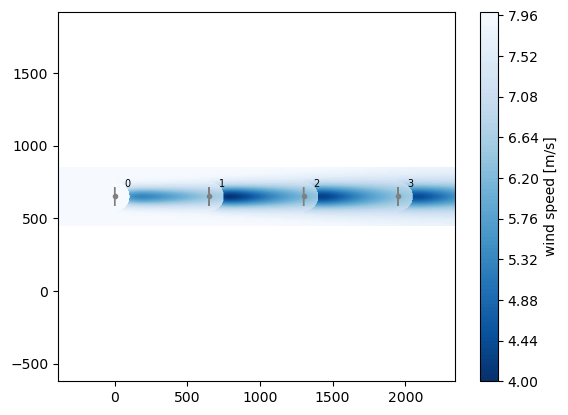

In [7]:
# %%prun
wt = iea3_4

u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=wt.diameter(),
                    hub_height=wt.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])

# Wind farm layout
D = wt.diameter()
x_turbines = np.array([0.0, 5, 10, 15]) * D  # [m]
y_turbines = np.array([5, 5.0, 5,5]) * D  # [m]

# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=None,
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))


# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site=site,
    windTurbines=wts,
    wake_deficitModel=deficit_model,
    superpositionModel=WeightedSum(),
    deflectionModel=JimenezWakeDeflection(),
    turbulenceModel=turbulence_model,
)


sim_res = wfm(
    x=x_turbines,
    y=y_turbines,
    type=np.full(4, True),  # Only first three turbines are active
    TI=np.full(1, 0.1),            # single turbulence intensity
    wd=np.full(1, 270),              # single wind direction
    ws=np.full(1, 8),              # single wind speed
    yaw=np.full(4, 0),        # array yaw values
    tilt=np.full(4, 0),      # array of tilt values
    time=True,
    power_demand=np.full(4, 50),     # array of power level values
)

sim_res.flow_map().plot_wake_map()  # this will take a long time





sim_res

In [8]:
# For the first turbine in the list (index 0)
print(wts.ct(ws=[8], type=[0], power_demand=[50]))
print(wts.ct(ws=[8], type=[0], power_demand=[100]))

# For the second turbine (index 1)
print(wts.ct(ws=[8], type=[1], power_demand=[50]))
print(wts.ct(ws=[8], type=[1], power_demand=[100]))


[0.]
[0.]
[0.6047624]
[0.81638676]


In [9]:
# %%prun
sa = compute_sector_average(sim_res, 
                            n_radius=10,
    n_azimuth=37,
    look="downwind")

# # print(sa.loc[{'quantity':'TI_eff'}])


In [11]:
# Predict loads using sector-averaged inflow
loads = predict_loads_sector_average(
    surrogates,   # dictionary of TensorflowSurrogate objects
    # sim_res,      # simulation result from PyWake
    sa,           # sector-averaged inflow (the variable `sa`)
    np.full(34, 30),   # additional input 1: yaw
    np.full(34, 100)  # additional input 2: power demand
)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
# drop the length-1 “time” dim
da = loads.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


In [ ]:
print(loads.coords)
print(loads.coords["name"].values)

df = pd.DataFrame(
    loads.squeeze(["wd", "ws"]).values,  # shape (6, 8)
    columns=loads.coords["name"].values,
    index=[f"T{i}" for i in range(loads.sizes["wt"])]
)

print(df)
